![KAUST Academy](https://i.imgur.com/a3uAqnb.png)

# Advanced RAG and Agentic RAG Lab

> **Goal:** Build one grounded RAG system, then add a small agent decision layer that chooses which documentation source to search.


## What You Will Learn

- Explain every stage of a complete RAG pipeline.
- Distinguish fast dense retrieval from precise Cross-Encoder reranking.
- Explain the key change from fixed RAG to Agentic RAG.
- Trace an agent's decision from routing to grounded answer.


## Setup

In Google Colab, select **Runtime -> Change runtime type -> T4 GPU**, then run the cells from top to bottom.


In [ ]:
%pip install -q -U \
  "datasets>=3,<5" \
  "langchain-core>=1.2,<2" \
  "langchain-text-splitters>=1.1,<2" \
  "transformers>=4.48,<6" \
  "sentence-transformers>=5.2,<6" \
  "faiss-cpu>=1.13" \
  accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.9/565.9 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.3/611.3 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 11.0 MB/s eta 0:00:00


In [ ]:
import re
from typing import Iterable

import faiss
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from IPython.display import Markdown, display
from sentence_transformers import CrossEncoder, SentenceTransformer
from transformers import AutoModelForCausalLM, AutoTokenizer

from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnableLambda
from langchain_text_splitters import RecursiveCharacterTextSplitter

torch.manual_seed(7)
pd.set_option("display.max_colwidth", 100)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Compute device: {DEVICE}")


Compute device: cuda


## Full RAG pipeline

<img src="https://huggingface.co/datasets/huggingface/cookbook-images/resolve/main/RAG_workflow.png" width="900" alt="Hugging Face RAG workflow" />

### OFFLINE — prepare the knowledge base

~~~text
Documentation
     -> LangChain Documents
     -> inspect token limits
     -> token-aware chunking
     -> remove duplicates
     -> embeddings
     -> FAISS
~~~

### ONLINE — answer each question

~~~text
Question
     -> Bi-Encoder dense retrieval (Top 30)
     -> Cross-Encoder reranking (Top 5)
     -> inspect retrieved passages
     -> prompt + context
     -> LLM
     -> grounded answer with correct citations
~~~


# Build the knowledge base

## Step 1 — Download the Hugging Face documentation

> **Question:** What information will our assistant be allowed to use?

We use `m-ric/huggingface_doc`, a documentation dataset hosted on the Hugging Face Hub.

- `text` contains documentation content.
- `source` identifies where the content came from.
- The dataset is downloaded once, before retrieval begins.

> **Important:** downloading and indexing belong to the offline phase. They do not run for every question.


In [ ]:
DATASET_ID = "m-ric/huggingface_doc"
documentation_dataset = load_dataset(DATASET_ID, split="train")

dataset_summary = pd.DataFrame(
    [
        {
            "dataset": DATASET_ID,
            "rows": len(documentation_dataset),
            "columns": ", ".join(documentation_dataset.column_names),
        }
    ]
)
display(dataset_summary)

dataset_preview = pd.DataFrame(
    [
        {
            "source": row["source"],
            "preview": row["text"][:120].replace("\n", " ") + "...",
        }
        for row in documentation_dataset.select(
            range(min(3, len(documentation_dataset)))
        )
    ]
)
display(dataset_preview)


README.md:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

huggingface_doc.csv: reconstructing file:   0%|          |  0.00B / 22.0MB            

huggingface_doc.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2647 [00:00<?, ? examples/s]

,dataset,rows,columns
0,m-ric/huggingface_doc,2647,"text, source"


,source,preview
0,huggingface/hf-endpoints-documentation/blob/main/docs/source/guides/create_endpoint.mdx,"Create an Endpoint After your first login, you will be directed to the [Endpoint creation page..."
1,huggingface/evaluate/blob/main/docs/source/choosing_a_metric.mdx,Choosing a metric for your task **So you've trained your model and want to see how well it’s d...
2,gradio-app/gradio/blob/main/guides/cn/01_getting-started/02_key-features.md,主要特点 让我们来介绍一下 Gradio 最受欢迎的一些功能！这里是 Gradio 的主要特点： 1. [添加示例输入](#example-inputs) 2. [传递自定义错误消息](...


## Step 2 — Convert rows into LangChain Documents

> **Question:** How do we keep every passage connected to its source?

A LangChain `Document` stores:

- `page_content`: searchable documentation text;
- `metadata`: the source and a stable document ID.

Metadata travels with every future chunk, which makes the final sources inspectable.


In [ ]:
raw_documents = [
    Document(
        page_content=row["text"],
        metadata={
            "source": row["source"],
            "document_id": document_id,
        },
    )
    for document_id, row in enumerate(documentation_dataset)
    if row["text"].strip()
]

document_summary = pd.DataFrame(
    [
        {
            "LangChain documents": len(raw_documents),
            "first source": raw_documents[0].metadata["source"],
            "first document characters": len(raw_documents[0].page_content),
        }
    ]
)
display(document_summary)


,LangChain documents,first source,first document characters
0,2647,huggingface/hf-endpoints-documentation/blob/main/docs/source/guides/create_endpoint.mdx,2013


# Retriever — Embeddings

The retriever is the search engine inside RAG. It converts documentation chunks and the question into vectors, then finds nearby meanings.


## Step 3 — Briefly inspect the rough chunks

> **Question:** Could the embedding model silently truncate a rough chunk?

Character count does not reliably predict token count because tokenizers split different words and symbols into different numbers of tokens.

The rough character splitter is used only for this quick diagnostic. It is not part of the final index.


In [ ]:
EMBEDDING_MODEL_ID = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDING_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_ID,
    device=EMBEDDING_DEVICE,
)
embedding_tokenizer = embedding_model.tokenizer
MODEL_MAX_TOKENS = embedding_model.max_seq_length

MARKDOWN_SEPARATORS = [
    r"\n#{1,6} ",   # Markdown headings: #, ##, ### ...
    r"\n```",       # code blocks
    r"\n\*\*\*+\n", # ***
    r"\n---+\n",    # ---
    r"\n___+\n",    # ___
    r"\n\n",        # paragraph break
    r"\n",          # line break
    r" ",           # space
    r"",            # last resort: split anywhere
]

rough_splitter = RecursiveCharacterTextSplitter(
    chunk_size=4000,
    chunk_overlap=400,
    separators=MARKDOWN_SEPARATORS,
    is_separator_regex=True,
    add_start_index=True,
    strip_whitespace=True,
)
rough_chunks = rough_splitter.split_documents(raw_documents)

print(f"Embedding model: {EMBEDDING_MODEL_ID}")
print(f"Actual max_seq_length: {MODEL_MAX_TOKENS} tokens")
print(f"Rough character-based chunks: {len(rough_chunks):,}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model: sentence-transformers/all-MiniLM-L6-v2
Actual max_seq_length: 256 tokens
Rough character-based chunks: 8,376


> **Diagnostic only:** The **8,376 rough chunks** are temporary. We inspect a few of them against the **256-token** model limit, then discard all rough chunks before building FAISS.


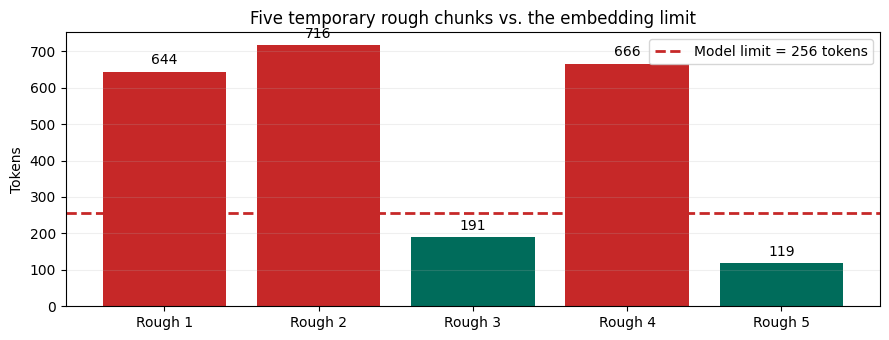

In [ ]:
# Inspect five actual rough chunks; these chunks are never indexed.
import matplotlib.pyplot as plt

sample_positions = np.linspace(
    0,
    len(rough_chunks) - 1,
    num=5,
    dtype=int,
)

original_tokenizer_limit = embedding_tokenizer.model_max_length
embedding_tokenizer.model_max_length = int(1e9)
sample_lengths = [
    len(
        embedding_tokenizer.encode(
            rough_chunks[position].page_content,
            add_special_tokens=True,
            truncation=False,
            verbose=False,
        )
    )
    for position in sample_positions
]
embedding_tokenizer.model_max_length = original_tokenizer_limit

labels = [f"Rough {index}" for index in range(1, 6)]
colors = [
    "#C62828" if length > MODEL_MAX_TOKENS else "#006C5B"
    for length in sample_lengths
]

figure, axis = plt.subplots(figsize=(9, 3.5))
bars = axis.bar(labels, sample_lengths, color=colors)
axis.axhline(
    MODEL_MAX_TOKENS,
    color="#C62828",
    linestyle="--",
    linewidth=2,
    label=f"Model limit = {MODEL_MAX_TOKENS} tokens",
)
axis.bar_label(bars, padding=3)
axis.set_ylabel("Tokens")
axis.set_title("Five temporary rough chunks vs. the embedding limit")
axis.legend()
axis.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


## Step 4 — Final token-aware chunking and duplicate removal

> **Question:** How do we create safe chunks for the real index?

| Setting | Value |
|---|---:|
| Embedding model limit | **256 tokens** |
| Final chunk target/maximum | **220 tokens** |
| Overlap | **30 tokens** |

`220` is a target/maximum, not an exact chunk size. The recursive splitter prefers natural Markdown boundaries, so many chunks are shorter.

The final process is:

- split with the embedding model's tokenizer;
- keep every chunk safely below the model limit;
- remove repeated chunk text;
- carry source metadata into the final FAISS index.

> **Main approach:** only these token-aware, deduplicated chunks are embedded and indexed.


In [ ]:
FINAL_CHUNK_TOKENS = 220
FINAL_OVERLAP_TOKENS = 30

if MODEL_MAX_TOKENS != 256:
    raise ValueError(
        f"Expected a 256-token embedding limit, received {MODEL_MAX_TOKENS}."
    )

chunking_configuration = pd.DataFrame(
    [
        {
            "embedding model limit": MODEL_MAX_TOKENS,
            "final chunk target/maximum": FINAL_CHUNK_TOKENS,
            "overlap": FINAL_OVERLAP_TOKENS,
        }
    ]
)
display(chunking_configuration)

token_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
    embedding_tokenizer,
    chunk_size=FINAL_CHUNK_TOKENS,
    chunk_overlap=FINAL_OVERLAP_TOKENS,
    separators=MARKDOWN_SEPARATORS,
    is_separator_regex=True,
    add_start_index=True,
    strip_whitespace=True,
)

candidate_chunks = token_splitter.split_documents(raw_documents)

chunks = []
seen_content = set()
duplicates_removed = 0

for candidate in candidate_chunks:
    duplicate_key = re.sub(r"\s+", " ", candidate.page_content).strip()
    if duplicate_key in seen_content:
        duplicates_removed += 1
        continue

    seen_content.add(duplicate_key)
    candidate.metadata["chunk_id"] = f"chunk-{len(chunks):06d}"
    chunks.append(candidate)

# Content-token counts exclude tokenizer-added special tokens.
chunk_token_lengths = [
    len(
        embedding_tokenizer.encode(
            chunk.page_content,
            add_special_tokens=False,
            truncation=False,
            verbose=False,
        )
    )
    for chunk in chunks
]

chunk_report = pd.DataFrame(
    [
        {
            "candidate chunks": len(candidate_chunks),
            "duplicates removed": duplicates_removed,
            "unique final chunks": len(chunks),
            "maximum content tokens": max(chunk_token_lengths),
            "chunk target/maximum": FINAL_CHUNK_TOKENS,
            "overlap tokens": FINAL_OVERLAP_TOKENS,
            "model limit": MODEL_MAX_TOKENS,
        }
    ]
)

display(chunk_report)

chunk_preview = pd.DataFrame(
    [
        {
            "chunk_id": chunk.metadata["chunk_id"],
            "source": chunk.metadata["source"],
            "content tokens": chunk_token_lengths[index],
            "preview": chunk.page_content[:100].replace("\n", " ") + "...",
        }
        for index, chunk in enumerate(chunks[:3])
    ]
)
display(chunk_preview)


,embedding model limit,final chunk target/maximum,overlap
0,256,220,30


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (398 > 256). Running this sequence through the model will result in indexing errors


,candidate chunks,duplicates removed,unique final chunks,maximum content tokens,chunk target/maximum,overlap tokens,model limit
0,47900,8115,39785,220,220,30,256


,chunk_id,source,content tokens,preview
0,chunk-000000,huggingface/hf-endpoints-documentation/blob/main/docs/source/guides/create_endpoint.mdx,178,"Create an Endpoint After your first login, you will be directed to the [Endpoint creation page]..."
1,chunk-000001,huggingface/hf-endpoints-documentation/blob/main/docs/source/guides/create_endpoint.mdx,192,"## 2. Select your Cloud Provider and region. Initially, only AWS will be available as a Cloud Pr..."
2,chunk-000002,huggingface/hf-endpoints-documentation/blob/main/docs/source/guides/create_endpoint.mdx,200,"## 4. Create your Endpoint by clicking **Create Endpoint**. By default, your Endpoint is created..."


## Step 5 — Create Embeddings and Build the Vector Index

> **Question:** How do we store chunks so we can search them by meaning?

Each unique chunk is converted into an **embedding vector** using `all-MiniLM-L6-v2`.

- Each chunk becomes a normalized **384-dimensional vector**.
- These vectors represent the semantic meaning of the chunks.
- The vectors are stored in a **FAISS vector index**.
- FAISS is not a full database here; it is a fast **vector search index** used to find the chunks most similar to a query.
- We use `IndexFlatIP`, which performs exact similarity search.

With normalized vectors:

```text
Inner Product ≈ Cosine Similarity
```

So the flow is:

```text
Chunk
  ↓
Embedding Model
  ↓
384-D Vector
  ↓
FAISS Vector Index
  ↓
Semantic Search
```

In [ ]:
chunk_texts = [chunk.page_content for chunk in chunks]

chunk_vectors = embedding_model.encode(
    chunk_texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True,
).astype("float32")

dense_index = faiss.IndexFlatIP(chunk_vectors.shape[1]) # Prepare Index (size 384 dim)
dense_index.add(chunk_vectors) # Adding the vectors into the Index

index_report = pd.DataFrame(
    [
        {
            "indexed chunks": dense_index.ntotal,
            "embedding dimensions": chunk_vectors.shape[1],
            "index": type(dense_index).__name__,
            "normalized vectors": True,
        }
    ]
)
display(index_report)


Batches:   0%|          | 0/622 [00:00<?, ?it/s]

,indexed chunks,embedding dimensions,index,normalized vectors
0,39785,384,IndexFlatIP,True


### Offline Phase Complete ✅

The knowledge base is now ready:

`Documents → Chunks → Embeddings → FAISS`

Next, we move to the **Online Phase**:

`Question → Retrieve → Rerank → Generate`

## Online Phase — Retrieve Candidates, Then Rerank

> **Question:** How do we find the most relevant passages for a user's question?

We use two stages:

### 1. Dense Retrieval with a Bi-Encoder

The question is converted into an embedding using the same embedding model used for the document chunks.

FAISS compares the **question vector** with all stored **chunk vectors** and retrieves the **Top 30 most similar passages**.

```text
Question
   ↓
Bi-Encoder
   ↓
Question Vector
   ↓
FAISS Vector Search
   ↓
Top 30 Candidates
```

### 2. (Optional) Reranking with a Cross-Encoder

The Cross-Encoder takes each of the 30 candidates and reads the **question and passage together**.

It gives each pair a relevance score, reranks the candidates, and keeps the **Best 5 passages**.

```text
Question + Candidate Passage
          ↓
     Cross-Encoder
          ↓
    Relevance Score
          ↓
     Rerank Top 30
          ↓
       Best 5
```

### Why use both?

- **Bi-Encoder + FAISS:** fast enough to search the entire vector index.
- **Cross-Encoder:** slower but more precise, so it is used only on the Top 30 candidates.

```text
Question
   ↓
Bi-Encoder + FAISS
   ↓
Top 30
   ↓
Cross-Encoder
   ↓
Best 5
   ↓
LLM
```

**In short:** `Bi-Encoder retrieves broadly → Cross-Encoder reranks precisely.`

## Step 6 — Bi-Encoder dense retrieval: Top 30

> **Question:** Why retrieve more passages than we give to the LLM?

The Bi-Encoder independently embeds the original question and every documentation chunk. FAISS then returns the 30 nearest vectors.

This broad shortlist protects recall: the next stage can only rerank passages that survive this retrieval step.


In [ ]:
def dense_search(question: str, k: int = 30) -> list[dict]:
    '''Retrieve the nearest chunks with the bi-encoder and FAISS.'''
    question_vector = embedding_model.encode(
        [question],
        normalize_embeddings=True,
        convert_to_numpy=True,
    ).astype("float32")

    # SEARCHING .. Nearest Vectors
    scores, positions = dense_index.search(
        question_vector,
        min(k, dense_index.ntotal),
    )

    return [
        {
            "document": chunks[position],
            "dense_score": float(score),
            "dense_rank": rank,
        }
        for rank, (score, position) in enumerate(
            zip(scores[0], positions[0]),
            start=1,
        )
        if position >= 0
    ]


def dense_results_table(
    results: list[dict],
    limit: int | None = None,
) -> pd.DataFrame:
    selected = results if limit is None else results[:limit]
    return pd.DataFrame(
        [
            {
                "dense rank": item["dense_rank"],
                "source": item["document"].metadata["source"],
                "dense score": round(item["dense_score"], 3),
                "preview": item["document"].page_content[:90].replace(
                    "\n", " "
                ) + "...",
            }
            for item in selected
        ]
    )


question = "How do I create a Transformers pipeline object for text generation?"
dense_candidates = dense_search(question, k=30)

display(
    pd.DataFrame(
        [{"requested candidates": 30, "retrieved candidates": len(dense_candidates)}]
    )
)
display(Markdown("#### First 10 of the 30 dense candidates"))
display(dense_results_table(dense_candidates, limit=10))


,requested candidates,retrieved candidates
0,30,30


#### First 10 of the 30 dense candidates

,dense rank,source,dense score,preview
0,1,huggingface/course/blob/main/chapters/en/chapter1/3.mdx,0.772,## Text generation[[text-generation]] Now let's see how to use a pipeline to generate som...
1,2,huggingface/course/blob/main/chapters/en/chapter1/3.mdx,0.714,"```python from transformers import pipeline generator = pipeline(""text-generation"", model..."
2,3,huggingface/blog/blob/main/tf-xla-generate.md,0.712,"The 🤗 `transformers` library started with NLP models, so it is natural that text generatio..."
3,4,huggingface/transformers/blob/main/docs/source/en/tasks/prompting.md,0.711,```python >>> from transformers import pipeline >>> import torch >>> torch.manual_seed(0)...
4,5,huggingface/course/blob/main/chapters/en/chapter1/6.mdx,0.669,These models are best suited for tasks involving text generation. Representatives of this...
5,6,huggingface/transformers/blob/main/docs/source/en/generation_strategies.md,0.650,"# Text generation strategies Text generation is essential to many NLP tasks, such as open..."
6,7,gradio-app/gradio/blob/main/demo/text_generation/run.ipynb,0.646,``` ``` import gradio as gr from transformers import pipeline generator = pipeline('tex...
7,8,huggingface/transformers/blob/main/docs/source/en/llm_tutorial.md,0.644,"# Generation with LLMs [[open-in-colab]] LLMs, or Large Language Models, are the key com..."
8,9,huggingface/transformers/blob/main/docs/source/en/tasks/prompting.md,0.638,"When using a pipeline to generate text with an LLM, it's important to know what type of LL..."
9,10,huggingface/hub-docs/blob/main/docs/hub/spaces-sdks-docker-first-demo.md,0.638,"```python from transformers import pipeline pipe_flan = pipeline(""text2text-generation"", ..."


## Step 7 — Cross-Encoder reranking: Top 5

> **Question:** Which of the 30 candidates answers this exact question most directly?

The Cross-Encoder reads each question-passage pair together and returns a **raw relevance score**. Higher means more relevant within this candidate set.


> **Limitation:** reranking can reorder retrieved candidates, but it cannot recover a passage missing from the original Top 30.


In [ ]:
RERANKER_MODEL_ID = "cross-encoder/ms-marco-MiniLM-L-6-v2"
reranker = CrossEncoder(
    RERANKER_MODEL_ID,
    device=DEVICE,
)


def rerank_candidates(
    question: str,
    candidates: list[dict],
    top_n: int = 5,
) -> list[dict]:
    '''Return the highest-scoring passages using raw relevance scores.'''
    if not candidates:
        return []

    pairs = [
        (question, item["document"].page_content)
        for item in candidates
    ]
    rerank_scores = reranker.predict(
        pairs,
        show_progress_bar=False,
    )

    scored = [
        {
            **item,
            "rerank_score": float(score),
        }
        for item, score in zip(candidates, rerank_scores)
    ]
    return sorted(
        scored,
        key=lambda item: item["rerank_score"],
        reverse=True,
    )[:top_n]


def reranked_results_table(results: list[dict]) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "final rank": final_rank,
                "previous dense rank": item["dense_rank"],
                "source": item["document"].metadata["source"],
                "reranker score": round(item["rerank_score"], 3),
                "passage preview": item["document"].page_content[:110].replace(
                    "\n", " "
                ) + "...",
            }
            for final_rank, item in enumerate(results, start=1)
        ]
    )


final_passages = rerank_candidates(
    question,
    dense_candidates,
    top_n=5,
)

display(Markdown("#### Inspect the best 5 passages after reranking"))
display(reranked_results_table(final_passages))


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

#### Inspect the best 5 passages after reranking

,final rank,previous dense rank,source,reranker score,passage preview
0,1,29,huggingface/blog/blob/main/megatron-training.md,6.654,# this creates a repository under your username with the model name codeparrot-small model.push_...
1,2,1,huggingface/course/blob/main/chapters/en/chapter1/3.mdx,6.230,## Text generation[[text-generation]] Now let's see how to use a pipeline to generate some text...
2,3,4,huggingface/transformers/blob/main/docs/source/en/tasks/prompting.md,6.195,```python >>> from transformers import pipeline >>> import torch >>> torch.manual_seed(0) # doc...
3,4,18,huggingface/blog/blob/main/falcon.md,6.162,"```python from transformers import AutoTokenizer import transformers import torch model = ""tiiu..."
4,5,11,huggingface/transformers/blob/main/docs/source/en/tasks/prompting.md,5.668,"### NLP tasks First, let's set up the environment: ```bash pip install -q transformers accel..."


## Inspect the reranked passages before generation

Compare **final rank** with **previous dense rank**. Large rank changes are normal because the Cross-Encoder evaluates the question and passage together.

Before running the LLM, confirm that the Top 5 passages:

- directly address the question;
- come from sensible sources;
- contain the facts or code the answer needs.

> **Teaching point:** never trust generation before inspecting the retrieved evidence that will enter its prompt.


# Reader — Grounded generation

Only after inspecting the Top 5 passages do we send them, with the original question, to the reader LLM.


## Step 8 — Build cited context and generate one grounded answer




In [ ]:
if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU detected. In Colab choose Runtime -> Change runtime type -> T4 GPU."
    )

GENERATOR_MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"

generator_tokenizer = AutoTokenizer.from_pretrained(GENERATOR_MODEL_ID)
generator_model = AutoModelForCausalLM.from_pretrained(
    GENERATOR_MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
)
generator_model.eval()

if generator_tokenizer.pad_token_id is None:
    generator_tokenizer.pad_token = generator_tokenizer.eos_token


def qwen_chat(
    system_prompt: str,
    user_prompt: str,
    max_new_tokens: int = 750,
) -> str:
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    inputs = generator_tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    ).to(generator_model.device)

    with torch.inference_mode():
        output = generator_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=generator_tokenizer.eos_token_id,
            eos_token_id=generator_tokenizer.eos_token_id,
        )

    new_tokens = output[0, inputs["input_ids"].shape[-1] :]
    return generator_tokenizer.decode(
        new_tokens,
        skip_special_tokens=True,
    ).strip()


def run_local_llm(prompt_value) -> str:
    prompt_text = (
        prompt_value.to_string()
        if hasattr(prompt_value, "to_string")
        else str(prompt_value)
    )
    return qwen_chat(
        (
            "Use only the supplied documentation. Never invent commands, "
            "model names, parameters, examples, or citations."
        ),
        prompt_text,
    )


local_llm = RunnableLambda(run_local_llm)
print(f"Loaded generator: {GENERATOR_MODEL_ID}")


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded generator: Qwen/Qwen2.5-3B-Instruct


In [ ]:
ANSWER_PROMPT = PromptTemplate.from_template(
    '''Answer the question using only the retrieved passages below.

Rules:
- Answer every part of the question that is supported by the retrieved passages.
- Provide enough explanation and code to fully answer the question.
- Include all distinct useful approaches found in the selected passages.
- Include code only when supported by a selected passage.
- Never invent installation commands, model names, parameters, or examples.
- Copy citations exactly from the CITATION lines after the claims they support.
- If a requested detail is unsupported, say: The retrieved documentation is insufficient for that detail.
- Keep the answer clear and practical, but do not omit supported information.

Citation example:
If a passage says
CITATION: [huggingface/course/blob/main/chapters/en/chapter1/3.mdx]
then cite it exactly as
[huggingface/course/blob/main/chapters/en/chapter1/3.mdx]

Question:
{question}

Retrieved passages:
{context}

Grounded answer:'''
)
answer_chain = ANSWER_PROMPT | local_llm | StrOutputParser()


def build_context(documents: Iterable[Document]) -> str:
    formatted_passages = []
    for passage_number, document in enumerate(documents, start=1):
        source = document.metadata["source"]
        formatted_passages.append(
            f"PASSAGE {passage_number}\n"
            f"CITATION: [{source}]\n"
            f"TEXT:\n{document.page_content}"
        )
    return "\n\n---\n\n".join(formatted_passages)


def generate_answer(
    question: str,
    documents: list[Document],
) -> str:
    return answer_chain.invoke(
        {
            "question": question,
            "context": build_context(documents),
        }
    )


# Complete RAG execution

The online path remains simple:

~~~text
question
     -> Bi-Encoder dense_search(k=30)
     -> Cross-Encoder rerank_candidates(top_n=5)
     -> inspect the Top 5 passages
     -> build cited context
     -> generate one grounded answer
~~~

We intentionally pause between retrieval and generation so the evidence is visible first.


In [ ]:
def retrieve_for_rag(
    question: str,
    candidate_k: int = 30,
    final_k: int = 5,
) -> dict:
    dense_candidates = dense_search(question, k=candidate_k)
    final_passages = rerank_candidates(
        question,
        dense_candidates,
        top_n=final_k,
    )
    return {
        "question": question,
        "dense_candidates": dense_candidates,
        "final_passages": final_passages,
    }


def show_retrieval(run: dict) -> None:
    display(Markdown("#### 1. Original question"))
    print(run["question"])

    display(Markdown("#### 2. Bi-Encoder retrieval: first 10 of Top 30"))
    display(
        pd.DataFrame(
            [{"dense candidates": len(run["dense_candidates"])}]
        )
    )
    display(dense_results_table(run["dense_candidates"], limit=10))

    display(Markdown("#### 3. Cross-Encoder reranking: final Top 5"))
    display(reranked_results_table(run["final_passages"]))


def answer_from_retrieval(run: dict) -> str:
    documents = [item["document"] for item in run["final_passages"]]
    return generate_answer(run["question"], documents)


In [ ]:
rag_retrieval = retrieve_for_rag(
    "How do I create a Transformers pipeline object for text generation?"
)
show_retrieval(rag_retrieval)


#### 1. Original question

How do I create a Transformers pipeline object for text generation?


#### 2. Bi-Encoder retrieval: first 10 of Top 30

,dense candidates
0,30


,dense rank,source,dense score,preview
0,1,huggingface/course/blob/main/chapters/en/chapter1/3.mdx,0.772,## Text generation[[text-generation]] Now let's see how to use a pipeline to generate som...
1,2,huggingface/course/blob/main/chapters/en/chapter1/3.mdx,0.714,"```python from transformers import pipeline generator = pipeline(""text-generation"", model..."
2,3,huggingface/blog/blob/main/tf-xla-generate.md,0.712,"The 🤗 `transformers` library started with NLP models, so it is natural that text generatio..."
3,4,huggingface/transformers/blob/main/docs/source/en/tasks/prompting.md,0.711,```python >>> from transformers import pipeline >>> import torch >>> torch.manual_seed(0)...
4,5,huggingface/course/blob/main/chapters/en/chapter1/6.mdx,0.669,These models are best suited for tasks involving text generation. Representatives of this...
5,6,huggingface/transformers/blob/main/docs/source/en/generation_strategies.md,0.650,"# Text generation strategies Text generation is essential to many NLP tasks, such as open..."
6,7,gradio-app/gradio/blob/main/demo/text_generation/run.ipynb,0.646,``` ``` import gradio as gr from transformers import pipeline generator = pipeline('tex...
7,8,huggingface/transformers/blob/main/docs/source/en/llm_tutorial.md,0.644,"# Generation with LLMs [[open-in-colab]] LLMs, or Large Language Models, are the key com..."
8,9,huggingface/transformers/blob/main/docs/source/en/tasks/prompting.md,0.638,"When using a pipeline to generate text with an LLM, it's important to know what type of LL..."
9,10,huggingface/hub-docs/blob/main/docs/hub/spaces-sdks-docker-first-demo.md,0.638,"```python from transformers import pipeline pipe_flan = pipeline(""text2text-generation"", ..."


#### 3. Cross-Encoder reranking: final Top 5

,final rank,previous dense rank,source,reranker score,passage preview
0,1,29,huggingface/blog/blob/main/megatron-training.md,6.654,# this creates a repository under your username with the model name codeparrot-small model.push_...
1,2,1,huggingface/course/blob/main/chapters/en/chapter1/3.mdx,6.230,## Text generation[[text-generation]] Now let's see how to use a pipeline to generate some text...
2,3,4,huggingface/transformers/blob/main/docs/source/en/tasks/prompting.md,6.195,```python >>> from transformers import pipeline >>> import torch >>> torch.manual_seed(0) # doc...
3,4,18,huggingface/blog/blob/main/falcon.md,6.162,"```python from transformers import AutoTokenizer import transformers import torch model = ""tiiu..."
4,5,11,huggingface/transformers/blob/main/docs/source/en/tasks/prompting.md,5.668,"### NLP tasks First, let's set up the environment: ```bash pip install -q transformers accel..."


In [ ]:
# Take the final Top 5 passages after reranking
final_documents = [
    item["document"]
    for item in rag_retrieval["final_passages"]
]

# Generate the full grounded answer
rag_answer = generate_answer(
    rag_retrieval["question"],
    final_documents,
)

# Collect unique sources used in the final passages
unique_sources = []
seen_sources = set()

for item in rag_retrieval["final_passages"]:
    source = item["document"].metadata["source"]

    if source not in seen_sources:
        seen_sources.add(source)
        unique_sources.append(source)

# Format sources
sources_markdown = "\n".join(
    f"{index}. `{source}`"
    for index, source in enumerate(unique_sources, start=1)
)

# Display final answer + sources
display(
    Markdown(
        f"""
## 4. Grounded Answer with Source Citations

{rag_answer}

---

### Sources Used

{sources_markdown}
"""
    )
)


## 4. Grounded Answer with Source Citations

To create a Transformers pipeline object for text generation, you can follow these steps based on the provided documentation:

1. **Using a pre-trained model**: You can use a pre-trained model by specifying its name. Here's how you can do it:

```python
from transformers import pipeline

generator = pipeline("text-generation")
generator("In this course, we will teach you how to")
```

This will generate text based on the prompt "In this course, we will teach you how to". The output might vary each time due to the random nature of text generation.

2. **Using a custom model**: If you have a custom model, you need to load the tokenizer and the model first, and then create a pipeline. Here's an example:

```python
from transformers import AutoTokenizer, pipeline

model_name = "your_username/codeparrot-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)
generator = pipeline("text-generation", model=model_name, tokenizer=tokenizer)

outputs = generator("def hello_world():")
print(outputs[0]["generated_text"])
```

This code snippet assumes you have already pushed your model to a hub and specified the correct model name. The output will be generated text based on the input prompt "def hello_world()".

Both methods allow you to generate text using a Transformers pipeline, depending on whether you are using a pre-trained model or a custom model.

---

### Sources Used

1. `huggingface/blog/blob/main/megatron-training.md`
2. `huggingface/course/blob/main/chapters/en/chapter1/3.mdx`
3. `huggingface/transformers/blob/main/docs/source/en/tasks/prompting.md`
4. `huggingface/blog/blob/main/falcon.md`


# Part 2 — From RAG to Agentic RAG

> **Question:** What changes when the model can choose the retrieval path?

## The One New Idea

Our RAG system already knows **how to retrieve and answer**. We will not rebuild it.

~~~text
RAG
Question → One retrieval path → Top 30 → Rerank Top 5 → Answer

Agentic RAG
Question → Router → Choose tool(s) → Top 30 per tool → Rerank Top 5 → Answer
~~~

> **Key idea:** RAG gives the LLM external knowledge. Agentic RAG also lets the LLM decide **how to obtain that knowledge**.

The chunks, embeddings, Cross-Encoder, prompt, and generator remain unchanged. Only the **decision layer** is new.


## **Which retrieval tool or source should be used?**


## Step 9 — Expose the Existing Knowledge Base as Tools

> **Question:** Why search every documentation family when the question needs only one or two?

A tool is a named capability the agent can select. Here, each tool searches one logical part of the **same indexed dataset**.

| Tool | Searches | Example question |
|---|---|---|
| `TRANSFORMERS` | Transformers documentation | How do I create a text-generation pipeline? |
| `GRADIO` | Gradio documentation | How do I create a Gradio interface? |
| `HUGGINGFACE` | Hub, course, and general Hugging Face documentation | How do I download a model from the Hub? |

> **Important:** These are not three new RAG systems. They are three filtered views of the existing chunks and embeddings.


In [ ]:
TOOL_DESCRIPTIONS = {
    "TRANSFORMERS": "Search the Hugging Face Transformers documentation.",
    "GRADIO": "Search the Gradio documentation.",
    "HUGGINGFACE": "Search Hub, course, and general Hugging Face documentation.",
}


def documentation_family(source: str) -> str:
    """Map a document source to one clear retrieval tool."""
    normalized_source = source.lower()

    if "gradio" in normalized_source:
        return "GRADIO"
    if "transformers" in normalized_source:
        return "TRANSFORMERS"
    return "HUGGINGFACE"


# Reuse the existing chunks and vectors; store only their positions per tool.
tool_chunk_positions = {tool_name: [] for tool_name in TOOL_DESCRIPTIONS}

for position, chunk in enumerate(chunks):
    family = documentation_family(chunk.metadata["source"])
    tool_chunk_positions[family].append(position)

tool_inventory = pd.DataFrame(
    [
        {
            "tool": tool_name,
            "description": TOOL_DESCRIPTIONS[tool_name],
            "available chunks": len(tool_chunk_positions[tool_name]),
        }
        for tool_name in TOOL_DESCRIPTIONS
    ]
)
display(tool_inventory)


def retrieve_with_tool(
    question: str,
    tool_name: str,
    candidate_k: int = 30,
) -> list[dict]:
    """Run dense retrieval inside one selected documentation family."""
    if tool_name not in tool_chunk_positions:
        raise ValueError(f"Unknown documentation tool: {tool_name}")

    allowed_positions = np.asarray(
        tool_chunk_positions[tool_name],
        dtype=np.int64,
    )
    if allowed_positions.size == 0:
        return []

    question_vector = embedding_model.encode(
        [question],
        normalize_embeddings=True,
        convert_to_numpy=True,
    ).astype("float32")[0]

    # Same normalized-vector similarity used by the original dense retriever.
    scores = chunk_vectors[allowed_positions] @ question_vector
    best_local_positions = np.argsort(-scores)[:candidate_k]

    return [
        {
            "document": chunks[int(allowed_positions[local_position])],
            "dense_score": float(scores[local_position]),
            "dense_rank": dense_rank,
            "tool": tool_name,
        }
        for dense_rank, local_position in enumerate(
            best_local_positions,
            start=1,
        )
    ]


,tool,description,available chunks
0,TRANSFORMERS,Search the Hugging Face Transformers documentation.,9685
1,GRADIO,Search the Gradio documentation.,4464
2,HUGGINGFACE,"Search Hub, course, and general Hugging Face documentation.",25636


## Step 10 — Add a Router Agent

> **Question:** What makes this agentic instead of another fixed RAG chain?

The local Qwen model now performs **two different roles**:

1. **Router:** decide which documentation tool or tools are needed.
2. **Answer generator:** write the final answer from the selected evidence.

The router may choose one tool:

~~~text
Question: How do I create a Gradio interface?
Decision: GRADIO
~~~

Or multiple tools:

~~~text
Question: How can I use a Transformers pipeline inside a Gradio app?
Decision: TRANSFORMERS + GRADIO
~~~

> **What changed:** The retrieval algorithm is still dense retrieval plus reranking. The agent now controls **which source family enters that pipeline**.


In [ ]:
ROUTER_SYSTEM_PROMPT = """You route technical questions to documentation tools.

Available tools:
- TRANSFORMERS: Transformers models, pipelines, tokenizers, training, and inference.
- GRADIO: Gradio interfaces, components, events, layouts, and apps.
- HUGGINGFACE: Hugging Face Hub, course, repositories, datasets, and general documentation.

Rules:
- Select every tool needed to answer the question.
- Return only tool names joined with +.
- Do not explain your decision.
- Valid examples: TRANSFORMERS, GRADIO, HUGGINGFACE, TRANSFORMERS+GRADIO.
"""


def route_question(question: str) -> dict:
    """Ask Qwen to select one or more documentation tools."""
    raw_decision = qwen_chat(
        ROUTER_SYSTEM_PROMPT,
        f"Question: {question}\nTool decision:",
        max_new_tokens=24,
    )

    normalized_decision = raw_decision.upper()
    selected_tools = [
        tool_name
        for tool_name in TOOL_DESCRIPTIONS
        if tool_name in normalized_decision
    ]

    # A safe deterministic fallback keeps the notebook runnable.
    if not selected_tools:
        selected_tools = ["HUGGINGFACE"]

    return {
        "raw_decision": raw_decision,
        "selected_tools": selected_tools,
    }


def agent_evidence_table(results: list[dict]) -> pd.DataFrame:
    """Show where each final passage came from and how its rank changed."""
    return pd.DataFrame(
        [
            {
                "final rank": final_rank,
                "tool": item["tool"],
                "previous dense rank": item["dense_rank"],
                "source": item["document"].metadata["source"],
                "reranker score": round(item["rerank_score"], 3),
                "passage preview": item["document"].page_content[:100].replace(
                    "\n", " "
                ) + "...",
            }
            for final_rank, item in enumerate(results, start=1)
        ]
    )


## Step 11 — Execute the Selected Tools and Show the Agent Trace

> **Question:** How can we see that the model made a decision before answering?

The control flow stays plain Python so every step is visible:

~~~text
Question
   ↓
Router decision
   ↓
Selected documentation tool(s)
   ↓
Dense retrieval: Top 30 from each selected tool
   ↓
Combine candidates and Cross-Encoder rerank: Top 5
   ↓
Inspect evidence
   ↓
Generate a grounded answer
~~~

The trace exposes the agent pattern:

> **Decision → Tool → Observation → Answer**

There are no retries, actions, or complex frameworks here. This minimal design isolates the one new concept: **agent-controlled retrieval**.


In [ ]:
def run_agentic_rag(
    question: str,
    candidate_k: int = 30,
    final_k: int = 5,
) -> dict:
    """Route, retrieve with selected tools, rerank, and answer."""
    route = route_question(question)

    candidates_by_tool = {}
    combined_candidates = []

    for tool_name in route["selected_tools"]:
        tool_candidates = retrieve_with_tool(
            question,
            tool_name,
            candidate_k=candidate_k,
        )
        candidates_by_tool[tool_name] = tool_candidates
        combined_candidates.extend(tool_candidates)

    final_passages = rerank_candidates(
        question,
        combined_candidates,
        top_n=final_k,
    )
    final_documents = [
        item["document"]
        for item in final_passages
    ]
    answer = generate_answer(question, final_documents)

    return {
        "question": question,
        "route": route,
        "candidates_by_tool": candidates_by_tool,
        "final_passages": final_passages,
        "answer": answer,
    }


def show_agentic_run(run: dict) -> None:
    """Display the decision, tool observations, evidence, and answer."""
    selected_tools = run["route"]["selected_tools"]
    candidate_counts = {
        tool_name: len(run["candidates_by_tool"][tool_name])
        for tool_name in selected_tools
    }

    trace = pd.DataFrame(
        [
            {"step": 1, "stage": "Question", "observation": run["question"]},
            {
                "step": 2,
                "stage": "Router decision",
                "observation": " + ".join(selected_tools),
            },
            {
                "step": 3,
                "stage": "Tools executed",
                "observation": ", ".join(
                    f"{tool}: {candidate_counts[tool]} candidates"
                    for tool in selected_tools
                ),
            },
            {
                "step": 4,
                "stage": "Cross-Encoder",
                "observation": f"Kept the best {len(run['final_passages'])} passages",
            },
            {
                "step": 5,
                "stage": "Grounded generation",
                "observation": "Answer only from the selected passages",
            },
        ]
    )

    display(Markdown("### Agent Trace"))
    display(trace)

    display(Markdown("### Final Evidence — Inspect Before Trusting the Answer"))
    display(agent_evidence_table(run["final_passages"]))

    display(Markdown("### Grounded Answer"))
    display(Markdown(run["answer"]))


## Try Three Routing Cases

Run exactly three examples:

1. **One Transformers tool** — verifies simple routing.
2. **One Gradio tool** — verifies that the same agent can choose a different path.
3. **Transformers + Gradio** — verifies multi-tool retrieval and combined reranking.

> **Before running:** Predict the selected tool or tools for each question. Then compare your prediction with the visible agent trace.


In [ ]:
agentic_questions = [
    "How do I create a Transformers pipeline for text generation?",
    "How do I create a Gradio interface?",
    "How can I use a Transformers text-generation pipeline inside a Gradio app?",
]

agentic_results = []

for example_number, agentic_question in enumerate(
    agentic_questions,
    start=1,
):
    display(Markdown(f"# Example {example_number}"))
    agentic_result = run_agentic_rag(agentic_question)
    agentic_results.append(agentic_result)
    show_agentic_run(agentic_result)
    display(Markdown("---"))


# Example 1

### Agent Trace

,step,stage,observation
0,1,Question,How do I create a Transformers pipeline for text generation?
1,2,Router decision,TRANSFORMERS + GRADIO
2,3,Tools executed,"TRANSFORMERS: 30 candidates, GRADIO: 30 candidates"
3,4,Cross-Encoder,Kept the best 5 passages
4,5,Grounded generation,Answer only from the selected passages


### Final Evidence — Inspect Before Trusting the Answer

,final rank,tool,previous dense rank,source,reranker score,passage preview
0,1,TRANSFORMERS,1,huggingface/transformers/blob/main/docs/source/en/tasks/prompting.md,6.539,```python >>> from transformers import pipeline >>> import torch >>> torch.manual_seed(0) # doc...
1,2,TRANSFORMERS,7,huggingface/transformers/blob/main/docs/source/en/tasks/prompting.md,5.858,"### NLP tasks First, let's set up the environment: ```bash pip install -q transformers accel..."
2,3,TRANSFORMERS,11,huggingface/hub-docs/blob/main/docs/hub/transformers.md,5.686,## Using existing models All `transformer` models are a line away from being used! Depending on...
3,4,GRADIO,1,gradio-app/gradio/blob/main/demo/text_generation/run.ipynb,5.667,``` ``` import gradio as gr from transformers import pipeline generator = pipeline('text-gene...
4,5,GRADIO,6,gradio-app/gradio/blob/main/demo/unified_demo_text_generation/run.ipynb,5.400,Gradio Demo: unified_demo_text_generation ``` !pip install -q gradio torch transformers ``` ...


...

### Final Evidence — Inspect Before Trusting the Answer

,final rank,tool,previous dense rank,source,reranker score,passage preview
0,1,GRADIO,1,gradio-app/gradio/blob/main/guides/06_integrating-other-frameworks/01_using-hugging-face-integra...,4.357,"``` But `gradio` actually makes it even easier to convert a `pipeline` to a demo, simply by usi..."
1,2,GRADIO,8,gradio-app/gradio/blob/main/guides/06_integrating-other-frameworks/01_using-hugging-face-integra...,4.206,## Demos with the `Pipeline` in `transformers` Hugging Face's popular `transformers` library ha...
2,3,GRADIO,3,gradio-app/gradio/blob/main/demo/unified_demo_text_generation/run.ipynb,3.491,Gradio Demo: unified_demo_text_generation ``` !pip install -q gradio torch transformers ``` ...
3,4,TRANSFORMERS,10,huggingface/hub-docs/blob/main/docs/hub/transformers.md,3.248,## Using existing models All `transformer` models are a line away from being used! Depending on...
4,5,GRADIO,4,gradio-app/gradio/blob/main/demo/text_generation/run.ipynb,2.980,``` ``` import gradio as gr from transformers import pipeline generator = pipeline('text-gene...


### Grounded Answer

To use a Transformers text-generation pipeline inside a Gradio app, you can follow these steps based on the provided documentation:

1. **Install Required Packages**: Ensure you have the necessary packages installed. You can install them using pip if they are not already installed.

   ```bash
   !pip install gradio transformers
   ```

2. **Import Necessary Libraries**: Import the required libraries including Gradio and the Transformers library.

   ```python
   import gradio as gr
   from transformers import pipeline
   ```

3. **Create a Pipeline**: Use the `pipeline` function from the Transformers library to create a text-generation pipeline. Specify the task and the model ID.

   ```python
   generator = pipeline('text-generation', model='gpt2')
   ```

4. **Define a Function for Prediction**: Define a function that takes input text and uses the pipeline to generate text. This function will be the core of your Gradio app.

   ```python
   def generate(text):
       result = generator(text, max_length=30, num_return_sequences=1)
       return result[0]["generated_text"]
   ```

5. **Create a Gradio Interface**: Create a Gradio interface that maps the input text to the generated text using the defined function.

   ```python
   demo = gr.Interface(fn=generate, inputs=gr.Textbox(lines=5, label="Input Text"), outputs=gr.Textbox(label="Generated Text"))
   ```

6. **Launch the App**: Finally, launch the Gradio app.

   ```python
   demo.launch()
   ```

Here is the complete code snippet:

```python
import gradio as gr
from transformers import pipeline

# Step 3: Create a Pipeline
generator = pipeline('text-generation', model='gpt2')

# Step 4: Define a Function for Prediction
def generate(text):
    result = generator(text, max_length=30, num_return_sequences=1)
    return result[0]["generated_text"]

# Step 5: Create a Gradio Interface
demo = gr.Interface(fn=generate, inputs=gr.Textbox(lines=5, label="Input Text"), outputs=gr.Textbox(label="Generated Text"))

# Step 6: Launch the App
demo.launch()
```

This code will create a Gradio app where users can input text and receive generated text as output.

---

## Final Comparison

<div style="max-width:900px; margin:auto; font-size:20px;">

<table style="width:100%; border-collapse:collapse; text-align:left;">

<tr>
<th style="padding:14px; border:1px solid #ccc; background:#f3f4f6;">
RAG
</th>
<th style="padding:14px; border:1px solid #ccc; background:#dcfce7;">
Agentic RAG
</th>
</tr>

<tr>
<td style="padding:14px; border:1px solid #ccc;">
<b>Fixed workflow</b>
</td>
<td style="padding:14px; border:1px solid #ccc;">
<b>Dynamic workflow</b>
</td>
</tr>

<tr>
<td style="padding:14px; border:1px solid #ccc;">
Retrieve → Generate
</td>
<td style="padding:14px; border:1px solid #ccc;">
Decide → Use Tool → Retrieve → Generate
</td>
</tr>

<tr>
<td style="padding:14px; border:1px solid #ccc;">
The developer defines the retrieval path.
</td>
<td style="padding:14px; border:1px solid #ccc;">
The agent can choose the retrieval path at runtime.
</td>
</tr>

<tr>
<td style="padding:14px; border:1px solid #ccc;">
Usually follows the same steps for every question.
</td>
<td style="padding:14px; border:1px solid #ccc;">
Can choose different tools or actions depending on the question.
</td>
</tr>

<tr>
<td style="padding:14px; border:1px solid #ccc;">
Main goal: <b>bring external knowledge to the LLM.</b>
</td>
<td style="padding:14px; border:1px solid #ccc; background:#f0fdf4;">
Main goal: <b>let the LLM decide how to obtain and use that knowledge.</b>
</td>
</tr>

</table>

</div>

# Thanks!

## Contributed by: Hussain Alyafei & Yazan Alshoibi